# Methane pyrolysis (TCD) hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LNM, and LCOH distributions, NPV sign counts, and mean annual cost components. Greenfield European methane pyrolysis; the natural-gas input is feedstock. The model has no solid-carbon by-product credit.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "methane_pyrolysis_tcd"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_th2,present_value_total_cost_eur,lcoh_eur_per_th2,levelized_net_margin_eur_per_th2
0,0,methane_pyrolysis_tcd,absolute,not_applicable,"100,000.000",25,"5,013.848",73.245,6.139,natural_gas,...,"136,477,873.383",0.000,0.000,"359,658,931.128","390,341,068.872","3,665,418,794.278","1,067,477.619","4,340,663,347.164","4,066.280","3,433.720"
1,1,methane_pyrolysis_tcd,absolute,not_applicable,"100,000.000",25,"6,068.236",89.989,5.644,natural_gas,...,"192,176,379.240",0.000,0.000,"443,683,847.703","306,316,152.297","2,663,032,766.165","1,067,477.619","5,343,049,375.277","5,005.303","2,494.697"
2,2,methane_pyrolysis_tcd,absolute,not_applicable,"100,000.000",25,"4,884.950",72.030,6.265,natural_gas,...,"126,655,907.335",0.000,0.000,"429,906,987.589","320,093,012.411","2,928,426,248.656","1,067,477.619","5,077,655,892.785","4,756.686","2,743.314"
3,3,methane_pyrolysis_tcd,absolute,not_applicable,"100,000.000",25,"6,130.720",107.294,8.730,natural_gas,...,"178,834,674.980",0.000,0.000,"436,980,528.149","313,019,471.851","2,728,340,829.131","1,067,477.619","5,277,741,312.311","4,944.124","2,555.876"
4,4,methane_pyrolysis_tcd,absolute,not_applicable,"100,000.000",25,"4,120.287",82.064,8.838,natural_gas,...,"99,852,240.238",0.000,0.000,"420,420,504.602","329,579,495.398","3,106,158,672.468","1,067,477.619","4,899,923,468.973","4,590.188","2,909.812"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_net_margin_eur_per_th2 = results["levelized_net_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,"3,357.313","3,145.090","4,354.910"
std,981.094,919.077,919.077
min,-290.823,-272.439,"1,985.268"
5%,"1,606.306","1,504.768","2,984.438"
50%,"3,441.018","3,223.504","4,276.496"
95%,"4,820.261","4,515.562","5,995.232"
max,"5,886.853","5,514.732","7,772.439"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),99980,1.000
1,Negative (NPV < 0),20,0.000


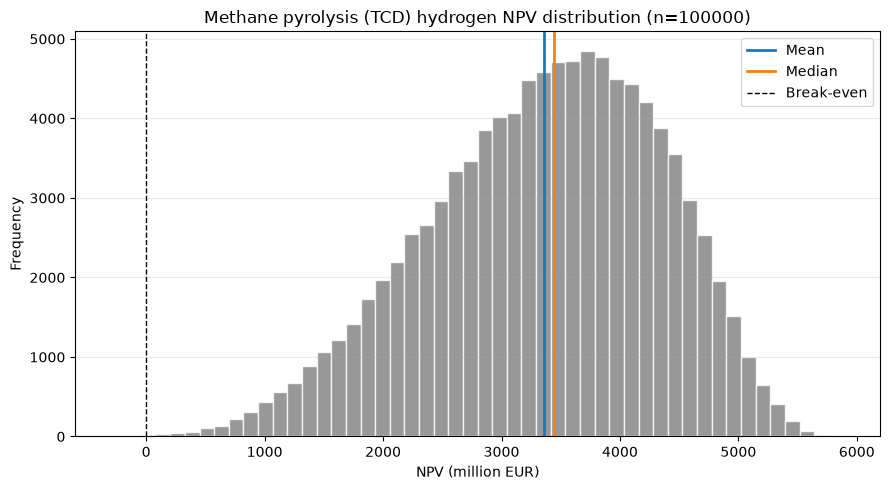

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Methane pyrolysis (TCD) hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

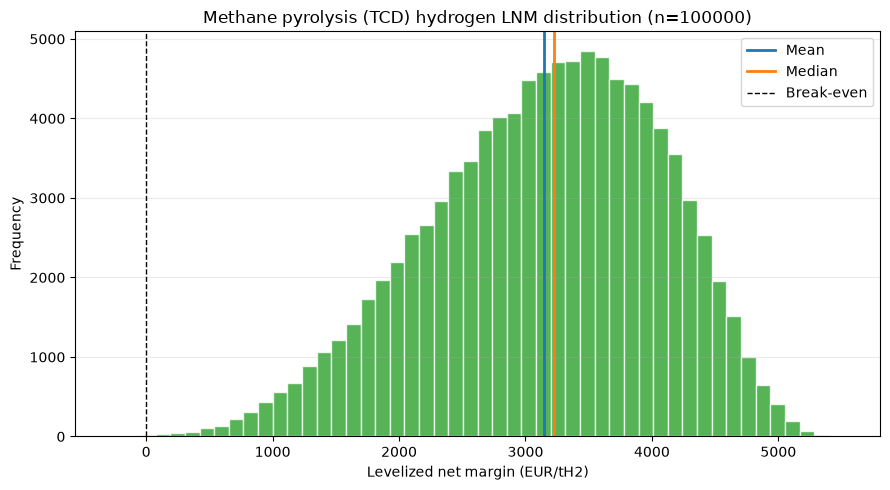

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_th2,
    title=f"Methane pyrolysis (TCD) hydrogen LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

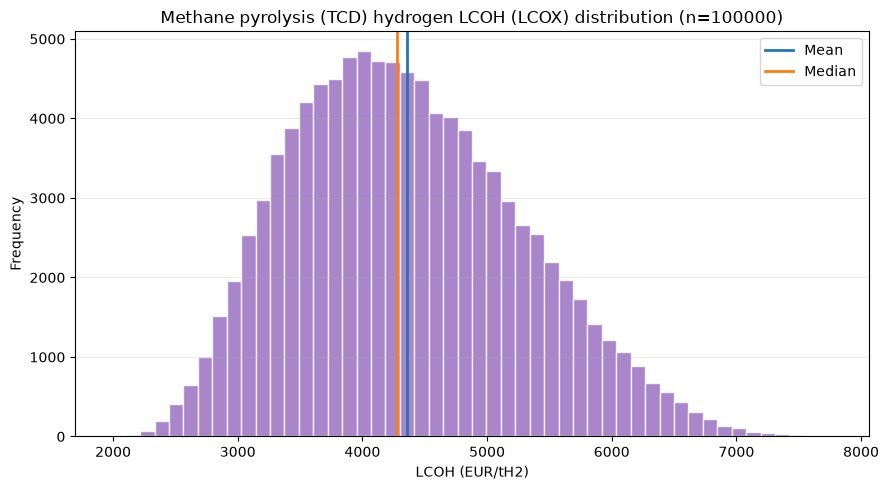

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"Methane pyrolysis (TCD) hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                     9.495
annual_variable_opex_eur                  0.747
annual_natural_gas_cost_eur             239.676
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    239.676
annual_electricity_cost_eur             132.884
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                367.198
Name: Mean annual value, million EUR, dtype: float64